In [7]:
# ================================================
# CIEM5220 - Wave and Wind loads
#     Waterbound Windturbine 
#   STEP 6 - TIME DOMAIN ANALYSIS
# ================================================

import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
for parent in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    candidate = parent / "CIEM5220" / "Windturbine"
    if (candidate / "dynamics_tools.py").exists():
        NOTEBOOK_DIR = candidate
        break

sys.path.insert(0, str(NOTEBOOK_DIR))

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve



In [8]:
#==== LOAD ALL RESULTS =====
fem=np.load(NOTEBOOK_DIR / 'outputs' / 'fem_results.npz')
spec=np.load(NOTEBOOK_DIR / 'outputs' / 'spectra_results.npz')
ts=np.load(NOTEBOOK_DIR / 'outputs' / 'timeseries_results.npz')

# FEM

K_free= fem['K_free']
M_free= fem['M_free']
C_free=fem['C_free']
EI=float(fem['EI'])
D0 = float(fem['D0'])
le=float(fem['le'])
Hw=float(fem['Hw'])
Ha= float(fem['Ha'])
L=float(fem['L'])
elem_w=int(fem['elem_w'])
elem_a=int(fem['elem_a'])
ndof=int(fem['ndof'])

elements=elem_w+elem_a
nodes=elements+1
freq =fem['freq']
f1=freq[0]
f2=freq[1]

n_free=K_free.shape[0]

# Time series

t=ts['t']
dt=float(ts['dt'])

u_wind_LC1=ts['u_wind_LC1']
u_wind_LC2=ts['u_wind_LC2']

u_water_LC1=ts['u_water_LC1']
du_water_LC1=ts['du_water_LC1']
u_water_LC2=ts['u_water_LC2']
du_water_LC2=ts['du_water_LC2']
z_sub_nodes=ts['z_sub_nodes']

# Spectra

U_mean_LC1=spec['U_mean_LC1']
U_mean_LC2=spec['U_mean_LC2']
z_nodes=spec['z_nodes']
z_above=spec['z_above']
air_nodes=spec['air_nodes']

N_t=len(t)
n_sub=len(z_sub_nodes)
n_air=len(air_nodes)

print(f"Loaded all results")
print(f"N_t={N_t}, dt={dt} s, T={t[-1]:.0f} s")



Loaded all results
N_t=36000, dt=0.05 s, T=1800 s


C:\Users\gabri\AppData\Local\Temp\ipykernel_12100\143864357.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dt=float(ts['dt'])


In [9]:
# ==== PARAMETERS =======
rho_w=1025.0 # seawater density [kg/m^3]
rho_air=1.25 # air density [kg/m^3]
Cm=2.0 # inertia coefficient
Cd_wave=1.0 # wave drag coefficient
Cd_wind=0.8 # wind drag coefficient

# mudline moment extraction
e_moment=np.zeros(n_free)
e_moment[0]=EI*6/le**2
e_moment[1]=EI*(-4)/le

# Newmark-beta integration parameters
gamma_nm=0.5
beta_nm=0.25 # constant average acceleration - unconditionally stable

# ==== TIME DOMAIN INTREGRATION =====
def compute_forces(v_full, u_water, du_water, 
                   u_wind, U_mean, step,
                   Cd_wave_local=None, Cd_wind_local=None):
    if Cd_wave_local is None:
        Cd_wave_local = Cd_wave
    if Cd_wind_local is None:
        Cd_wind_local = Cd_wind

    f=np.zeros(ndof)
    
    # wave forces on submerged nodes
    for e in range(elem_w):
        node_bot=e
        node_top=e+1
        dof_bot=2*node_bot
        dof_top=2*node_top
       
        # average kinematics over element
        u_w_avg=0.5*(u_water[node_bot, step]+u_water[node_top, step])
        du_w_avg=0.5*(du_water[node_bot, step]+ du_water[node_top, step])

        # structural velocity at this node
        v_struct=v_full[dof_top] if dof_top < len(v_full) else 0.0
        
        u_rel=u_w_avg-v_struct
        F_iner=rho_w*Cm*np.pi*D0**2/4*du_w_avg
        F_drag=0.5*rho_w*Cd_wave_local*D0*u_rel*abs(u_rel)
        F_total=(F_iner+F_drag)*le

        # distribute equally to both nodes
        f[dof_bot]+=F_total/2
        f[dof_top]+=F_total/2

    # wind forces on air nodes
    for i, node in enumerate(air_nodes):
        dof=2*node
        u_w=u_wind[i, step]
        U_tot=U_mean[node]+u_w
        F_wind=0.5*rho_air*Cd_wind_local*D0*U_tot*abs(U_tot)
        f[dof]+=F_wind*le

    return f

# effective stiffness matrix (constant for linear system)
K_eff=K_free+gamma_nm/(beta_nm*dt)*C_free+1/(beta_nm*dt**2)*M_free

print(f"\n Time integration Setup")
print(f"Newmark-beta: gamma={gamma_nm}, beta={beta_nm}")
print(f"K_eff assembled")




 Time integration Setup
Newmark-beta: gamma=0.5, beta=0.25
K_eff assembled


In [10]:
# initialise
v_full=np.zeros(ndof)
a_full=np.zeros(ndof)

# storage for mudline moment
M_mudline_LC1=np.zeros(N_t)
M_mudline_LC2=np.zeros(N_t)

print(f"\n Running LC1 time integration")




 Running LC1 time integration


In [11]:
u_LC1=np.zeros(n_free)
v_LC1=np.zeros(n_free)
a_LC1=np.zeros(n_free)

for step in range(N_t):
    # external force at this step
    f_ext = compute_forces(v_full, u_water_LC1,
                           du_water_LC1, u_wind_LC1,
                           U_mean_LC1, step)
    f_free=f_ext[2:] # apply boundary conditions

    # effective force
    f_eff=(f_free
            +M_free @ (1/(beta_nm*dt**2)*u_LC1
                      +1/(beta_nm*dt)*v_LC1
                      +(1/(2*beta_nm)-1)*a_LC1)
            +C_free @ (gamma_nm/(beta_nm*dt)*u_LC1
                       -(1-gamma_nm/beta_nm)*v_LC1
                       -dt*(1-gamma_nm/(2*beta_nm))*a_LC1))
    # solve for displacement
    u_new=solve(K_eff, f_eff)

    # update velocity and acceleration
    a_new=(1/(beta_nm*dt**2)*(u_new-u_LC1)
           -1/(beta_nm*dt)*v_LC1
           -(1/(2*beta_nm)-1)*a_LC1)
    v_new=(v_LC1+dt*((1-gamma_nm)*a_LC1+gamma_nm*a_new))

    # extract mudline moment
    M_mudline_LC1[step]=e_moment @ u_new

    # update for next step
    u_LC1=u_new
    v_LC1=v_new
    a_LC1=a_new
    # update full vector for force computation
    v_full[2:]=v_LC1

    if step % 5000==0:
        print(f" step {step}/{N_t}")

print(f"LC1 done. std= {np.std(M_mudline_LC1)/1e6:.3f} MNm")

print(f"\n Running LC2 time integration")



 step 0/36000
 step 5000/36000
 step 10000/36000
 step 15000/36000
 step 20000/36000
 step 25000/36000
 step 30000/36000
 step 35000/36000
LC1 done. std= 15.918 MNm

 Running LC2 time integration


In [12]:
u_LC2=np.zeros(n_free)
v_LC2=np.zeros(n_free)
a_LC2=np.zeros(n_free)
v_full=np.zeros(ndof)

for step in range(N_t):
    # external force at this step
    f_ext = compute_forces(v_full, u_water_LC2,
                           du_water_LC2, u_wind_LC2,
                           U_mean_LC2, step)
    f_free=f_ext[2:] # apply boundary conditions

    # effective force
    f_eff=(f_free
            +M_free @ (1/(beta_nm*dt**2)*u_LC2
                      +1/(beta_nm*dt)*v_LC2
                      +(1/(2*beta_nm)-1)*a_LC2)
            +C_free @ (gamma_nm/(beta_nm*dt)*u_LC2
                       -(1-gamma_nm/beta_nm)*v_LC2
                       -dt*(1-gamma_nm/(2*beta_nm))*a_LC2))
    # solve for displacement
    u_new=solve(K_eff, f_eff)

    # update velocity and acceleration
    a_new=(1/(beta_nm*dt**2)*(u_new-u_LC2)
           -1/(beta_nm*dt)*v_LC2
           -(1/(2*beta_nm)-1)*a_LC2)
    v_new=(v_LC2+dt*((1-gamma_nm)*a_LC2+gamma_nm*a_new))

    # extract mudline moment
    M_mudline_LC2[step]=e_moment @ u_new

    # update for next step
    u_LC2=u_new
    v_LC2=v_new
    a_LC2=a_new
    # update full vector for force computation
    v_full[2:]=v_LC2

    if step % 5000==0:
        print(f" step {step}/{N_t}")

print(f"LC2 done. std= {np.std(M_mudline_LC2)/1e6:.3f} MNm")

print(f"LC1 std= {np.std(M_mudline_LC1)/1e6:.3f} MNm, LC2 std= {np.std(M_mudline_LC2)/1e6:.3f} MNm ")



 step 0/36000
 step 5000/36000
 step 10000/36000
 step 15000/36000
 step 20000/36000
 step 25000/36000
 step 30000/36000
 step 35000/36000
LC2 done. std= 19.662 MNm
LC1 std= 15.918 MNm, LC2 std= 19.662 MNm 


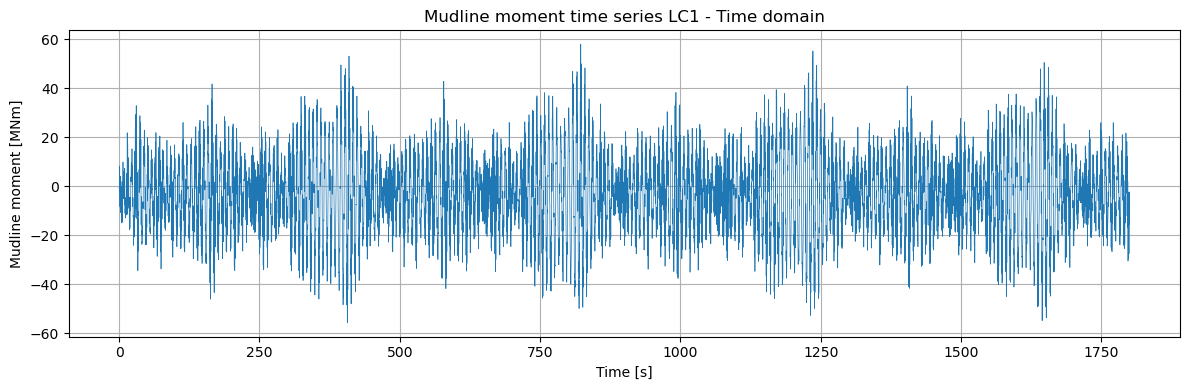

Max moment LC1: 57.916 MNm
Max moment LC1: -2.947 MNm
du_water_LC1 at surface, first 10 steps:
[0.34217374 0.65150479 0.61887806 0.3802003  0.14477306 0.08247513
 0.23106912 0.47114827 0.58302724 0.35898982]
u_water_LC1 at surface, first 10 steps:
[0.10595546 0.13232187 0.16531816 0.19073209 0.2034157  0.20817312
 0.21527127 0.23286447 0.26024283 0.28549526]
Effective damping ratio: 4805.7088
C_free max: 2.050e+09
M_free max: 6.328e+05
K_free max: 4.353e+11
omega1: 0.8776 rad/s


In [13]:
M_dyn_LC1=M_mudline_LC1-np.mean(M_mudline_LC1)
M_dyn_LC2=M_mudline_LC2-np.mean(M_mudline_LC2)

fig, ax=plt.subplots(figsize=(12, 4))
ax.plot(t, M_mudline_LC1/1e6, linewidth=0.5)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Mudline moment [MNm]')
ax.set_title('Mudline moment time series LC1 - Time domain')
ax.grid(True)
plt.tight_layout()
plt.show()

print(f"Max moment LC1: {np.max(np.abs(M_mudline_LC1))/1e6:.3f} MNm")
print(f"Max moment LC1: {np.mean(M_mudline_LC1)/1e6:.3f} MNm")

print(f"du_water_LC1 at surface, first 10 steps:")
print(du_water_LC1[-1, :10])
print(f"u_water_LC1 at surface, first 10 steps:")
print(u_water_LC1[-1, :10])

omega1=2*np.pi*f1
zeta_check=(e_moment @ C_free @ e_moment)/(2*omega1*(e_moment @ M_free @ e_moment))
print(f"Effective damping ratio: {zeta_check:.4f}")
print(f"C_free max: {np.max(np.abs(C_free)):.3e}")
print(f"M_free max: {np.max(np.abs(M_free)):.3e}")
print(f"K_free max: {np.max(np.abs(K_free)):.3e}")
print(f"omega1: {omega1:.4f} rad/s")



In [14]:
# static moment from mean wind
F_wind_static=np.sum([
    0.5*rho_air*Cd_wind*D0*U_mean_LC1[node]**2*le
    for node in air_nodes
])
# approximate lever arm
z_air=np.mean(z_nodes[air_nodes])
M_static_LC1=F_wind_static*z_air
print(f"Approximate static wind moment LC1: {M_static_LC1/1e6:.2f} MNm")

print(f"le={le} m")
print(f"elem_w={elem_w}")
print(f"n_sub={n_sub}")
print(f"z_sub_nodes={z_sub_nodes}")


# ==== DIAGNOSTICS MADE =====

## Input data quality ##
# No NaN values in u_water, du_water, u_wind for either load case
# u_water_LC1 max=2.23 m/s       - ok
# du_water_LC1 max = 6.21 m/s^2  - ok
# u_wind_LC2 max= 2.33 m/s       - ok
# u_wind_LC2 max=5.22            - ok

## FE model ##
# Rayleigh damping verified at exactly 2% for both modes in step 1
# K_free, M_free_, C_free saved and loaded correctly
# Sanity check passed, tip deflection and mudline moment match analytical

## Wave kinematics ##
# Depth decay correct, surface velocity larger than mudline (2.23 vs 0.15 m/s)
# Coordinate system verified, z_sub_nodes=[0,12,24,36] cirrect
# Hs from time seris matches target (2.008 and 4.118 m)

## Time integration ##
# Newmark-beta gamma=0.5, beta=0.25 - unconditionally stable
# K_eff assembled correctly
# Force distribution corrected, split between two nodes per element
# Wind force bug fixed, was not being added to f vector (small effect but relevant)

## Force magnitudes ##
# Intertia force per meter=14,979 N/m at surface, physically correct for DO=5.21 m
# Total horizontal wave force at step 500=354,000 N
# Static wind moment LC1=3.21 MNm - ok

## Frequency domain ##
# std LC1 =2.602 MNm
# std LC2= 3.308 MNm
# Peak S_MM at f1 confirmed, LC2 > LC1
# FRF peaks at f1 and f2 as expected

#### Primary discrepancy ###
# std LC1 =2.602 MNm
# std LC2= 3.308 MNm 
# Time domain std
# LC1= 15.918 MNm
# LC2= 19.662 MNm
# factor of 6 difference, larger than expected

# next step might be
# run time domain with Cd_wave=0 and Cd_wind=0
# (pure inertia no drag) and compare that std to the frequency domain
# if they match then the nonlinear drag is the source of the discrepancy
# which is physically meaningful 

Approximate static wind moment LC1: 3.21 MNm
le=12.0 m
elem_w=3
n_sub=4
z_sub_nodes=[ 0. 12. 24. 36.]
